In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import LabelEncoder



In [4]:
# Loding the dataset and inspecting it 

df = pd.read_csv("steps_tracker_dataset.csv")
df.columns = df.columns.str.strip()  

print("Dataset Preview:")
print(df.head())


print("Shape of the dataset:", df.shape)
print()
print("Column names:", df.columns)
print()
print("Dataframe Information:")
print(df.info())
print()
print("Statistical Summary:")
print(df.describe())

Dataset Preview:
         date  steps  distance_km  calories_burned  active_minutes  \
0  08/10/2022   4147         3.11           124.41              41   
1  11/06/2022    323         0.24             9.69               3   
2  28/01/2022   6622         4.97           198.66              66   
3  23/03/2022  11136         8.35           334.08             111   
4  20/05/2022   2718         2.04            81.54              27   

   sleep_hours  water_intake_liters      mood  
0         10.5                 3.77  stressed  
1          6.0                 1.90       sad  
2          6.0                 4.48       sad  
3          8.0                 1.08     tired  
4          4.9                 1.00     tired  
Shape of the dataset: (500, 8)

Column names: Index(['date', 'steps', 'distance_km', 'calories_burned', 'active_minutes',
       'sleep_hours', 'water_intake_liters', 'mood'],
      dtype='object')

Dataframe Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50

In [5]:
# Since this is not a time series problem, we can drop the date column and focus on the features that influence calories burned.

df.drop(columns=["date"], inplace=True)
print(df.head())


print("Shape of the dataset:", df.shape)
print()
print("Column names:", df.columns)
print()
print("Dataframe Information:")
print(df.info())
print()
print("Statistical Summary:")
print(df.describe())

   steps  distance_km  calories_burned  active_minutes  sleep_hours  \
0   4147         3.11           124.41              41         10.5   
1    323         0.24             9.69               3          6.0   
2   6622         4.97           198.66              66          6.0   
3  11136         8.35           334.08             111          8.0   
4   2718         2.04            81.54              27          4.9   

   water_intake_liters      mood  
0                 3.77  stressed  
1                 1.90       sad  
2                 4.48       sad  
3                 1.08     tired  
4                 1.00     tired  
Shape of the dataset: (500, 7)

Column names: Index(['steps', 'distance_km', 'calories_burned', 'active_minutes',
       'sleep_hours', 'water_intake_liters', 'mood'],
      dtype='object')

Dataframe Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dty

In [6]:
#CHecking for missing values in the dataset
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
steps                  0
distance_km            0
calories_burned        0
active_minutes         0
sleep_hours            0
water_intake_liters    0
mood                   0
dtype: int64


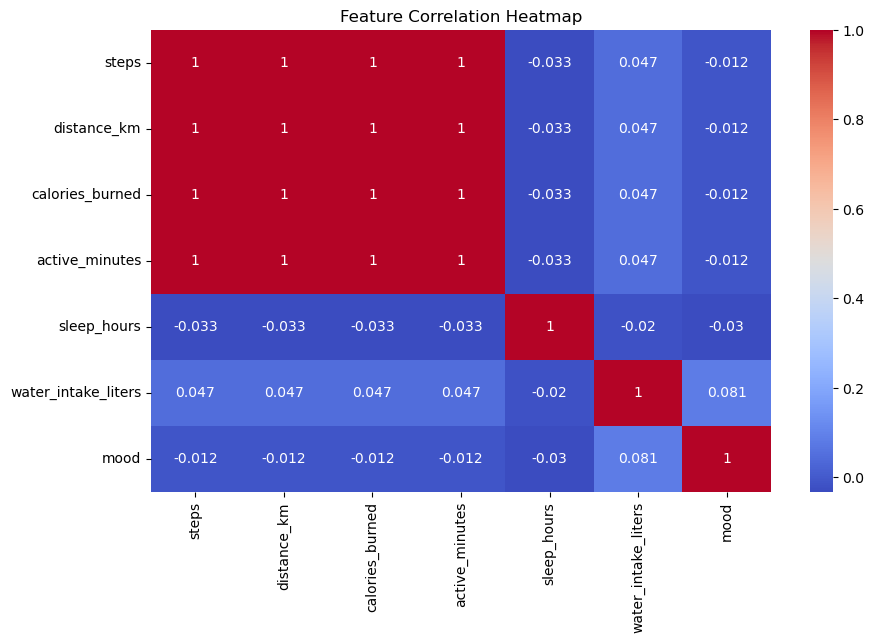

In [7]:
# Analyzing the data and finding correlations between features and the target variable (calories_burned)
plt.figure(figsize=(10, 6))


label_encoder = LabelEncoder()
df["mood"] = label_encoder.fit_transform(df["mood"])

corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()


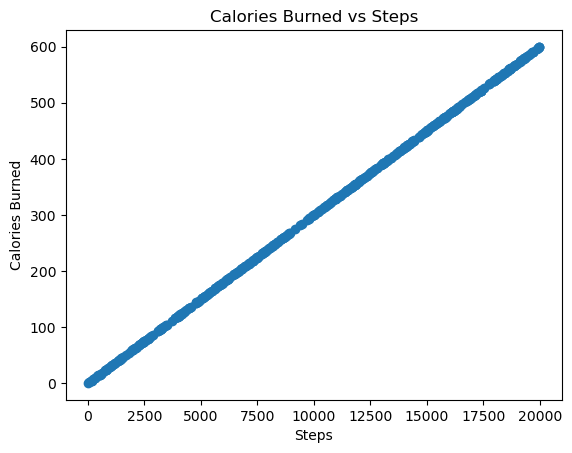

In [8]:
# From the heatmap, we can see that steps, active_minutes, and distance_km have a strong positive correlation with calories_burned. While all the other features have a weak correlation with calories_burned.

# We can use these features to train a model that predicts the caloriesburned based on the input data.

#Going to create chart to better understand the relationship between steps and calories. 

plt.plot (df["steps"], df["calories_burned"], "o")
plt.xlabel("Steps")
plt.ylabel("Calories Burned")
plt.title("Calories Burned vs Steps")
plt.show()

In [9]:
# The relatioship is very clear between steps and calories burned.

# Going to remove all other columns so we can focus on the relationship between calories burned and steps, distance_km, and active_minutes.

df.drop(columns=["mood", "water_intake_liters", "sleep_hours"], inplace=True)
print(df.head())

df.to_csv("cleaned_fitness_data.csv", index=False)

   steps  distance_km  calories_burned  active_minutes
0   4147         3.11           124.41              41
1    323         0.24             9.69               3
2   6622         4.97           198.66              66
3  11136         8.35           334.08             111
4   2718         2.04            81.54              27
